In [20]:
%cd /Users/gregyoungforever/Documents/ISEP2024\-2025/CZ/ML/Exercises/final_project

/Users/gregyoungforever/Documents/ISEP2024-2025/CZ/ML/Exercises/final_project


In [21]:
from omegaconf import OmegaConf
from src.analysis.dataset_analyzer import SpectrogramDatasetAnalyzer

cfg = OmegaConf.create({
    "paths": {
        "train_image_dir": "./datasets/x_train",
        "test_image_dir": "./datasets/x_test",
        "train_label_file": "./datasets/y_train.csv",
    }
})

analyzer = SpectrogramDatasetAnalyzer(cfg=cfg)
report = analyzer.build_dataset_summary()

2026-04-09 10:39:18 | INFO | src.analysis.dataset_analyzer | Loaded 9227 training samples.
2026-04-09 10:39:18 | INFO | src.analysis.dataset_analyzer | Loaded 3955 test samples.
2026-04-09 10:39:18 | INFO | src.analysis.dataset_analyzer | Built dataset summary tables for notebook usage.


In [22]:
report["train_image_stats"]

,image_id,width,height,pixel_mean,pixel_std,pixel_min,pixel_max
0,1183,51,45,53.921425,5.025326,51.0,173.333328
1,1038,51,45,60.257668,6.820039,51.0,173.333328
2,9216,51,45,53.865650,4.241523,51.0,173.333328
3,908,51,45,54.620621,4.737665,51.0,173.333328
4,8491,51,45,52.606243,4.068849,51.0,173.333328
...,...,...,...,...,...,...,...
251,119,51,45,54.285984,5.082318,51.0,173.333328
252,5562,51,45,53.960350,4.034422,51.0,173.333328
253,4972,51,45,53.714592,3.896448,51.0,173.333328
254,1615,51,45,54.745678,4.827406,51.0,173.333328


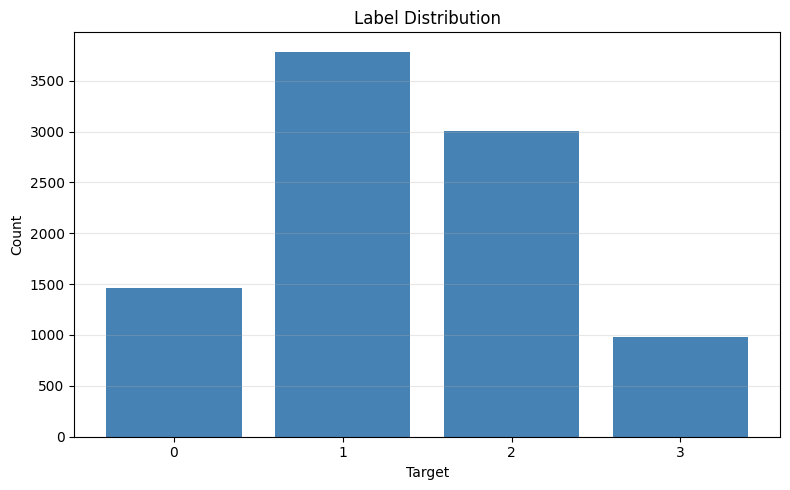

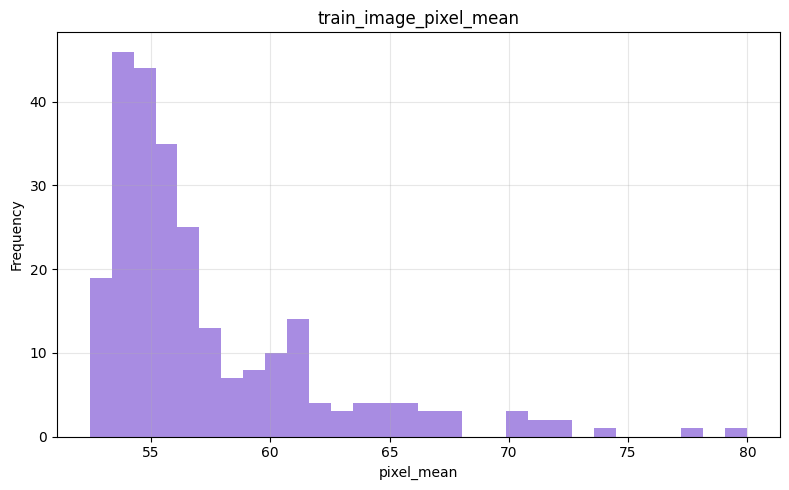

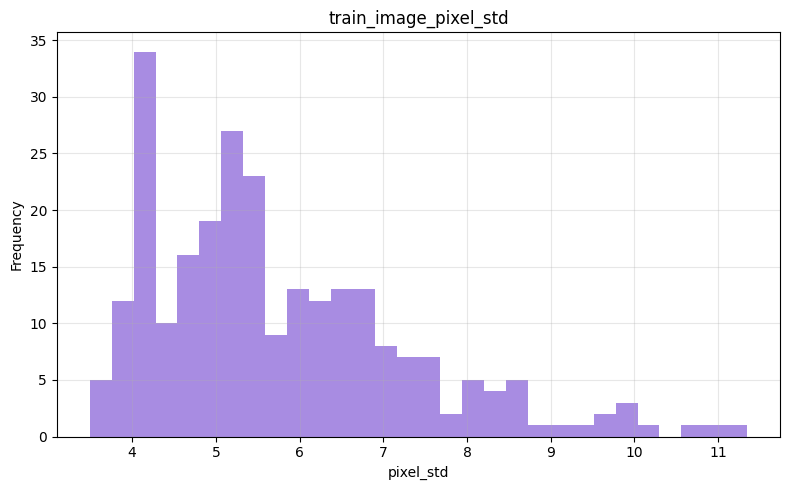

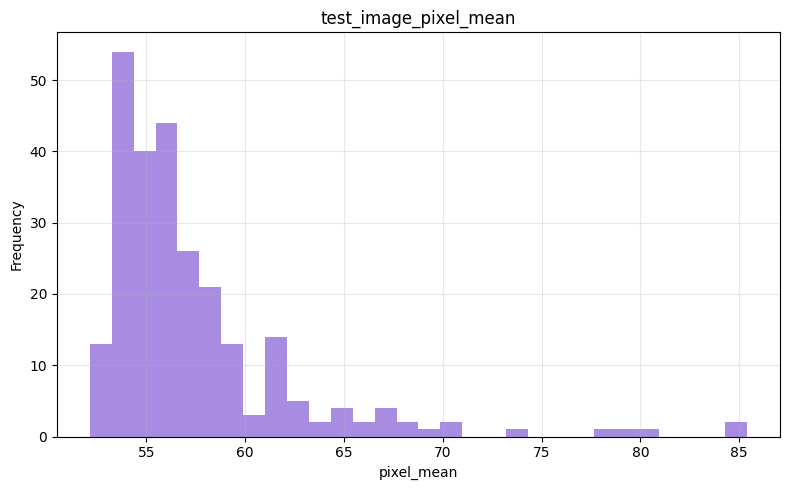

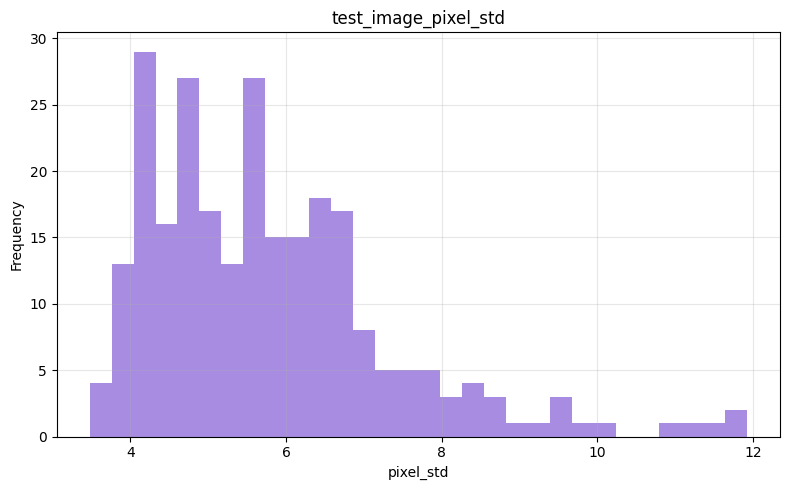

In [23]:
from src.utils.visualization import SpectrogramVisualizer
visualizer = SpectrogramVisualizer()
report["label_distribution"].to_csv("./reports/tables/label_distribution.csv", index=False)
fig, ax = visualizer.plot_label_distribution(report["label_distribution"])
fig, ax = visualizer.plot_stat_histogram(report["train_image_stats"],column="pixel_mean",title="train_image_pixel_mean")
fig, ax = visualizer.plot_stat_histogram(report["train_image_stats"],column="pixel_std",title="train_image_pixel_std")
fig, ax = visualizer.plot_stat_histogram(report["test_image_stats"],column="pixel_mean",title="test_image_pixel_mean")
fig, ax = visualizer.plot_stat_histogram(report["test_image_stats"],column="pixel_std",title="test_image_pixel_std")